In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

df = pl.scan_parquet("out/*.parquet", missing_columns='insert', extra_columns="ignore").collect().cast({
    "compression_time" : pl.Duration('ns'),
    "decompression_time" : pl.Duration('ns'),
})

In [2]:
df1 = df.select(
    ["trace", "alg", "clevel", "compressed_size", "compression_time", "decompression_time"]
).group_by(
    ["trace", "alg", "clevel"]
).mean()

In [3]:
df2 = df1.filter([
    pl.col("trace") == "spec-all",
    pl.col("alg") == "zlib",
]).sort(
    "clevel"
).with_columns(
    (4096 / pl.col("compressed_size")).alias("ratio"),
    ((4096e3) / pl.col("compression_time").dt.total_nanoseconds()).alias("rate")
)

df3 = df1.with_columns(
    (4096 / pl.col("compressed_size")).alias("ratio"),
    ((4096e3) / pl.col("compression_time").dt.total_nanoseconds()).alias("rate")
)

df3

trace,alg,clevel,compressed_size,compression_time,decompression_time,ratio,rate
str,str,i32,f64,duration[ns],duration[ns],f64,f64
"""work-medium""","""zstd""",9,603.907787,1293990ns,7942ns,6.782492,3.165403
"""work-medium""","""lz4""",0,1472.082727,6974ns,2714ns,2.782452,587.324348
"""build-llvm""","""lz4""",1,4027.116989,1975ns,1536ns,1.017105,2073.924051
"""spec-all""","""lzo""",3,1639.467491,76619ns,9809ns,2.498372,53.459325
"""spec-all""","""lz4""",9,1986.7114,10942ns,2886ns,2.061699,374.337415
…,…,…,…,…,…,…,…
"""spec-all""","""lz4""",0,1986.7114,10408ns,3063ns,2.061699,393.543428
"""ollama""","""zstd""",7,3284.739293,351235ns,7160ns,1.246979,11.661708
"""work-small""","""lz4""",0,1282.956427,8650ns,3177ns,3.192626,473.526012


In [9]:
df3.filter(
    pl.col("trace") == "work-medium",
    pl.col("clevel") == 0,
    #pl.col("alg") == "zstd"
).sort("clevel")

trace,alg,clevel,compressed_size,compression_time,decompression_time,ratio,rate
str,str,i32,f64,duration[ns],duration[ns],f64,f64
"""work-medium""","""lz4""",0,1472.082727,6974ns,2714ns,2.782452,587.324348
"""work-medium""","""zstd""",0,626.570263,20823ns,7640ns,6.537176,196.705566
"""work-medium""","""zlib""",0,812.975734,226577ns,25329ns,5.038281,18.07774
"""work-medium""","""lzo""",0,1275.028017,7443ns,4926ns,3.212478,550.315733


In [12]:
df3.filter(
    pl.col("trace") == "work-medium",
    #pl.col("clevel") == 0,
    pl.col("alg") == "zstd"
).sort("clevel")

trace,alg,clevel,compressed_size,compression_time,decompression_time,ratio,rate
str,str,i32,f64,duration[ns],duration[ns],f64,f64
"""work-medium""","""zstd""",0,626.570263,20823ns,7640ns,6.537176,196.705566
"""work-medium""","""zstd""",1,621.831458,21997ns,7595ns,6.586994,186.20721
"""work-medium""","""zstd""",2,621.831458,21881ns,7603ns,6.586994,187.19437
"""work-medium""","""zstd""",3,614.657622,43647ns,7565ns,6.663872,93.843792
"""work-medium""","""zstd""",4,613.276859,131678ns,7369ns,6.678876,31.106183
"""work-medium""","""zstd""",5,613.24465,150274ns,7526ns,6.679227,27.256877
"""work-medium""","""zstd""",6,606.107434,547934ns,8016ns,6.757878,7.475353
"""work-medium""","""zstd""",7,604.881756,637826ns,7918ns,6.771571,6.421814
"""work-medium""","""zstd""",8,603.951688,1241114ns,8016ns,6.781999,3.300261


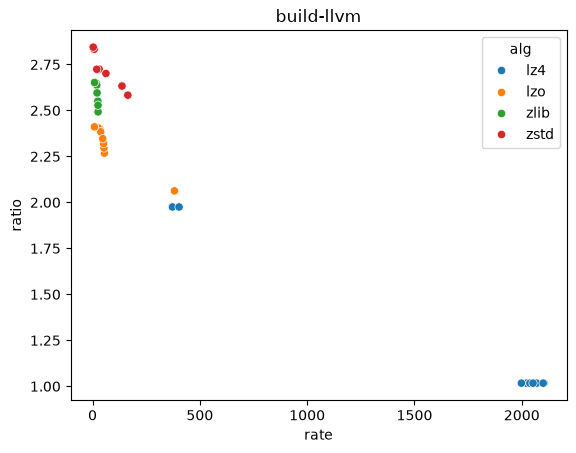

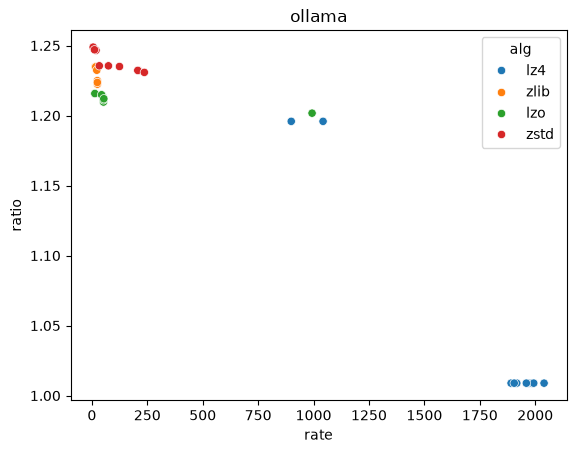

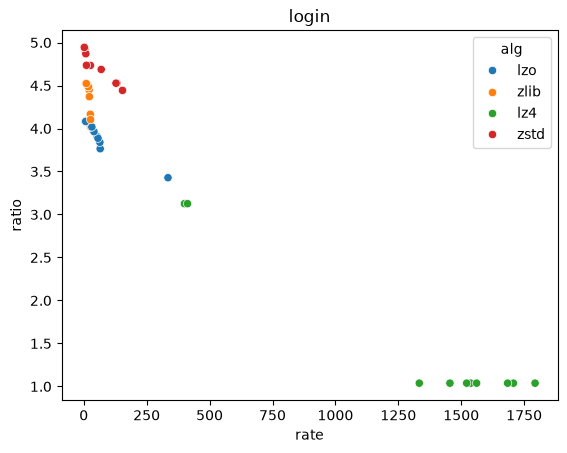

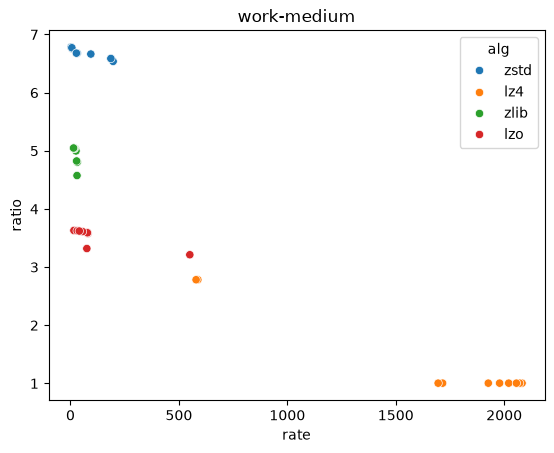

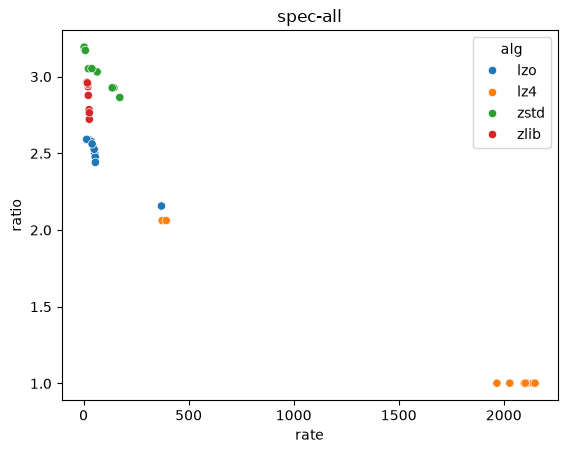

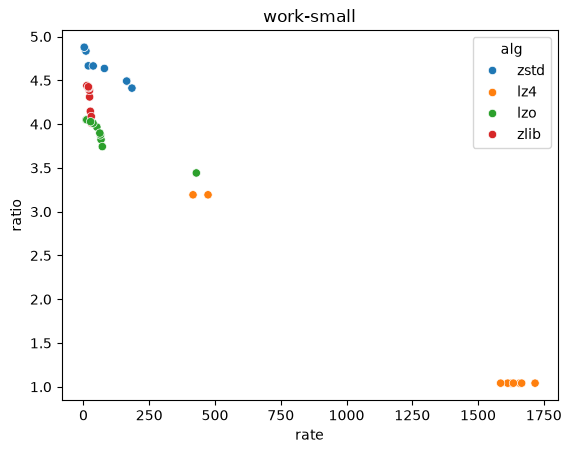

In [5]:
for trace in df["trace"].unique().to_list():
    df4 = df3.filter(pl.col("trace") == trace)

    plt.figure()
    sns.scatterplot(
        df4,
        x="rate",
        y="ratio",
        hue="alg"
    )
    plt.title(f"{trace}")

In [6]:
df1 = df.filter(
    pl.col("alg") == "zlib"
)

print(df1.group_by("clevel").mean().select(["clevel", "compressed_size", "compression_time", "decompression_time"]))

shape: (10, 4)
┌────────┬─────────────────┬──────────────────┬────────────────────┐
│ clevel ┆ compressed_size ┆ compression_time ┆ decompression_time │
│ ---    ┆ ---             ┆ ---              ┆ ---                │
│ i32    ┆ f64             ┆ duration[ns]     ┆ duration[ns]       │
╞════════╪═════════════════╪══════════════════╪════════════════════╡
│ 6      ┆ 1550.062742     ┆ 227433ns         ┆ 34543ns            │
│ 3      ┆ 1608.964735     ┆ 163254ns         ┆ 30406ns            │
│ 9      ┆ 1547.396576     ┆ 405787ns         ┆ 34398ns            │
│ 0      ┆ 1550.062742     ┆ 223356ns         ┆ 34692ns            │
│ 1      ┆ 1645.481153     ┆ 156351ns         ┆ 31153ns            │
│ 4      ┆ 1579.17982      ┆ 190520ns         ┆ 35066ns            │
│ 7      ┆ 1548.205781     ┆ 251308ns         ┆ 34705ns            │
│ 8      ┆ 1547.35076      ┆ 356948ns         ┆ 34486ns            │
│ 5      ┆ 1555.916683     ┆ 203707ns         ┆ 34531ns            │
│ 2      ┆ 1621.641

KeyboardInterrupt: 

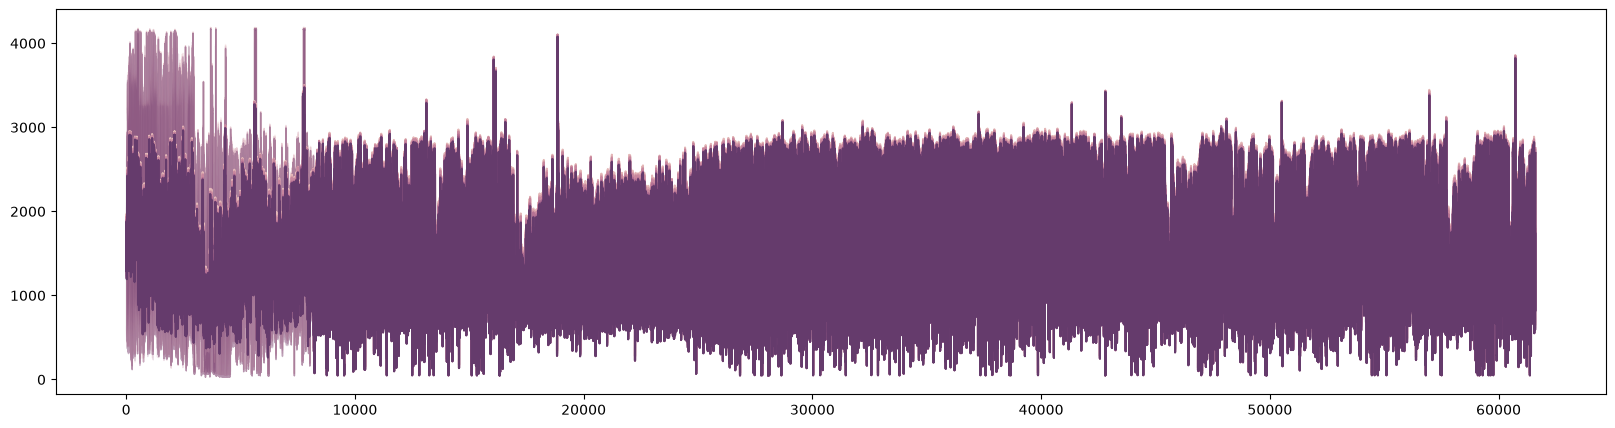

In [7]:

plt.figure(figsize=(20,5))
sns.lineplot(
    df1,
    x="page_number",
    y="compressed_size",
    hue="clevel"
)

plt.figure(figsize=(20,5))
sns.lineplot(
    df1,
    x="page_number",
    y="compression_time",
    hue="clevel"
)